In [28]:
from langchain_openai import ChatOpenAI
from langgraph_supervisor import create_supervisor
from langchain.agents import create_agent

from typing import TypedDict 
from langgraph.graph import StateGraph, START, END

from IPython.display import Image, display
from dotenv import load_dotenv
import os

load_dotenv()

True

In [2]:
model = ChatOpenAI(model="gpt-4o")

In [3]:
# Create specialized agents

def add(a: float, b: float) -> float:
    """Add two numbers."""
    return a + b

def multiply(a: float, b: float) -> float:
    """Multiply two numbers."""
    return a * b

def web_search(query: str) -> str:
    """Search the web for information."""
    return (
        "Here are the headcounts for each of the FAANG companies in 2024:\n"
        "1. **Facebook (Meta)**: 67,317 employees.\n"
        "2. **Apple**: 164,000 employees.\n"
        "3. **Amazon**: 1,551,000 employees.\n"
        "4. **Netflix**: 14,000 employees.\n"
        "5. **Google (Alphabet)**: 181,269 employees."
    )

In [6]:
math_agent = create_agent(
    model=model,
    tools=[add, multiply],
    name="math_expert",
    system_prompt="You are a math expert. Always use one tool at a time."
)

In [7]:
research_agent = create_agent(
    model=model,
    tools=[web_search],
    name="research_expert",
    system_prompt="You are a world class researcher with access to web search. Do not do any math."
)

In [8]:
workflow = create_supervisor(
    [research_agent, math_agent],
    model=model,
    prompt=(
        "You are a team supervisor managing a research expert and a math expert. "
        "For current events, use research_agent. "
        "For math problems, use math_agent."
    )
)

In [10]:
app = workflow.compile()

In [12]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'supervisor': Node(id='supervisor', name='supervisor', data=<langgraph.graph.state.CompiledStateGraph object at 0x12820a380>, metadata=None), 'research_expert': Node(id='research_expert', name='research_expert', data=call_agent(tags=None, recurse=True, explode_args=False, func_accepts={'config': ('N/A', <class 'inspect._empty'>)}), metadata=None), 'math_expert': Node(id='math_expert', name='math_expert', data=call_agent(tags=None, recurse=True, explode_args=False, func_accepts={'config': ('N/A', <class 'inspect._empty'>)}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='supervisor', data=None, conditional=False), Edge(source='math_expert', target='supervisor', data=None, conditional=False), Edge(source='research_expert', target='supervisor',

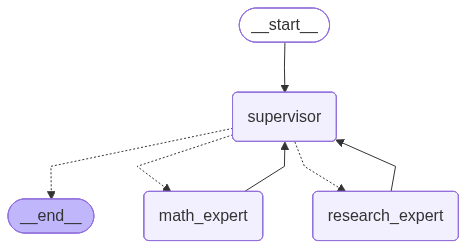

In [26]:
display(Image(app.get_graph().draw_mermaid_png()))

In [13]:
result = app.invoke({
    "messages": [
        {
            "role": "user",
            "content": "what's the combined headcount of the FAANG companies in 2024?"
        }
    ]
})

In [25]:
result['messages'][1].content_blocks

[{'type': 'tool_call',
  'name': 'transfer_to_research_expert',
  'args': {},
  'id': 'call_EeJSy74DFrbsFP8Uh4Oei3Lw'}]

In [29]:
class InputState(TypedDict):
    user_input: str

class OutputState(TypedDict):
    graph_output: str

class OverallState(TypedDict):
    foo: str
    user_input: str
    graph_output: str

class PrivateState(TypedDict):
    bar: str

def node_1(state: InputState) -> OverallState:
    # Write to OverallState
    return {"foo": state["user_input"] + " name"}

def node_2(state: OverallState) -> PrivateState:
    # Read from OverallState, write to PrivateState
    return {"bar": state["foo"] + " is"}

def node_3(state: PrivateState) -> OutputState:
    # Read from PrivateState, write to OutputState
    return {"graph_output": state["bar"] + " Lance"}

builder = StateGraph(OverallState,input_schema=InputState,output_schema=OutputState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", "node_3")
builder.add_edge("node_3", END)

graph = builder.compile()
graph.invoke({"user_input":"My"})
# {'graph_output': 'My name is Lance'}

{'graph_output': 'My name is Lance'}

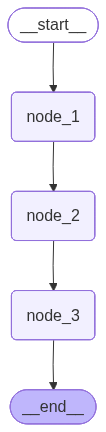

In [31]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
agent = create_agent("openai:gpt-5.4", tools=[], name="research_assistant")


In [35]:
result = agent.invoke(
    {"messages": [{"role": "user", "content": "What are the properties of the PLZT?"}]},
)

In [37]:
from langchain.messages import AIMessage, HumanMessage

for chunk in agent.stream({
    "messages": [{"role": "user", "content": "Search for AI news and summarize the findings"}]
}, stream_mode="values"):
    # Each chunk contains the full state at that point
    latest_message = chunk["messages"][-1]
    if latest_message.content:
        if isinstance(latest_message, HumanMessage):
            print(f"User: {latest_message.content}")
        elif isinstance(latest_message, AIMessage):
            print(f"Agent: {latest_message.content}")
    elif latest_message.tool_calls:
        print(f"Calling tools: {[tc['name'] for tc in latest_message.tool_calls]}")

User: Search for AI news and summarize the findings
Agent: Here’s a concise roundup of notable recent AI news and developments:

---

## 1. **OpenAI’s “Operator” & Agentic AI Trends**
OpenAI has rolled out or previewed more **agent-like capabilities**—AI systems that can act on your behalf (e.g., navigating websites, completing tasks), often referred to as **“Operator”** or “AI agents.” This reflects a broader industry shift from chatbots toward **autonomous task completion**.  
**Why it matters:** AI is moving beyond answering questions into actually **doing things**—booking, searching, summarizing, coding, and workflow automation.

---

## 2. **Google Expands Gemini Across Products**
Google continues integrating **Gemini** into Search, Workspace, Android, and Cloud. New updates emphasize:
- better reasoning,
- multimodal input (text, image, audio, video),
- stronger enterprise tooling,
- and AI assistants embedded in everyday apps.  
**Why it matters:** Google is making AI a default 

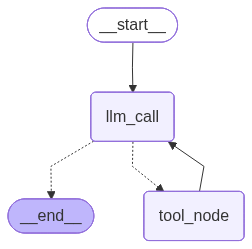

================================ Human Message =================================

Add 3 and 4 and divide on 4. Repeat five times.
================================== Ai Message ==================================
Tool Calls:
  add (call_gdUTeZtHL1d3mifOHV5sWBay)
 Call ID: call_gdUTeZtHL1d3mifOHV5sWBay
  Args:
    a: 3
    b: 4
  add (call_u5rFnmRkuTMuPcsFjEuDBVJG)
 Call ID: call_u5rFnmRkuTMuPcsFjEuDBVJG
  Args:
    a: 3
    b: 4
  add (call_uFGajYV6qxr2KYaBijSkv008)
 Call ID: call_uFGajYV6qxr2KYaBijSkv008
  Args:
    a: 3
    b: 4
  add (call_JzL6mScAwRghp3cWyPoz9dW3)
 Call ID: call_JzL6mScAwRghp3cWyPoz9dW3
  Args:
    a: 3
    b: 4
  add (call_xnDb3We17d5LjGu9JezwY5mL)
 Call ID: call_xnDb3We17d5LjGu9JezwY5mL
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7
================================= Tool Message =================================

7
================================= Tool Message =================================

7
=====

In [42]:
# Step 1: Define tools and model

from langchain.tools import tool
from langchain.chat_models import init_chat_model


model = init_chat_model(
    "gpt-4o",
    temperature=0
)


# Define tools
@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b


# Augment the LLM with tools
tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools)

# Step 2: Define state

from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
import operator


class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llm_calls: int

# Step 3: Define model node
from langchain.messages import SystemMessage


def llm_call(state: MessagesState):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            model_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )
                ]
                + state["messages"]
            )
        ],
        "llm_calls": state.get('llm_calls', 0) + 1
    }


# Step 4: Define tool node

from langchain.messages import ToolMessage


def tool_node(state: MessagesState):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}

# Step 5: Define logic to determine whether to end

from typing import Literal
from langgraph.graph import StateGraph, START, END


# Conditional edge function to route to the tool node or end based upon whether the LLM made a tool call
def should_continue(state: MessagesState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]

    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "tool_node"

    # Otherwise, we stop (reply to the user)
    return END

# Step 6: Build agent

# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)
agent_builder.add_edge("tool_node", "llm_call")

# Compile the agent
agent = agent_builder.compile()


from IPython.display import Image, display
# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

# Invoke
from langchain.messages import HumanMessage
messages = [HumanMessage(content="Add 3 and 4 and divide on 4. Repeat five times.")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

In [43]:
messages

{'messages': [HumanMessage(content='Add 3 and 4 and divide on 4. Repeat five times.', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 101, 'prompt_tokens': 171, 'total_tokens': 272, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_2c2fc4f892', 'id': 'chatcmpl-Dlj7qZlpF0GL4A1vmhY2y7VZSAGy2', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e8032-734f-71c3-b435-ed353565db71-0', tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 4}, 'id': 'call_gdUTeZtHL1d3mifOHV5sWBay', 'type': 'tool_call'}, {'name': 'add', 'args': {'a': 3, 'b': 4}, 'id': 'call_u5rFnmRkuTMuPcsFjEuDBVJG', 'type': 'tool_call'}, 